# Pushcart Prize Analysis - Part 1: Data Collection & Gold Standard

**CMPE-257 Machine Learning - NLP Assignment**

**Team:** TheRandomForest  
**Student:** Jaya Vyas

---

## Rubric Alignment

- ✅ **Step 0:** Scrape Pushcart nominations (gold standard)
- ✅ **Step 0:** Scrape pedestrian poems (comparison set)
- ✅ **Step 1:** POS distributions with plots
- ✅ **Step 2:** Topic modeling (LDA)
- ✅ **Step 3:** Sentiment analysis
- ✅ **Step 4:** Delta analysis

**Output:** Gold standard profile for use in Part 2 (FCoT Evolution)

## Setup: Install Packages

In [1]:
!pip install -q nltk gensim sentence-transformers scikit-learn textblob vaderSentiment \
    matplotlib seaborn pandas numpy beautifulsoup4 requests lxml pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.8 MB/s eta 0:00:00


In [2]:
import json
import os
import re
import time
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from gensim import corpora, models
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('stopwords', quiet=True)

print("✓ All imports successful")

✓ All imports successful


## Configuration

In [3]:
# Output directory
OUTPUT_DIR = './pushcart_data/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Output directory: ./pushcart_data/


## STEP 0: Data Collection

### Option 1: Upload Pre-collected Poems

If you've already collected poems, upload them here:

In [4]:
from google.colab import files

print("Upload your JSON files:")
print("  - pushcart_poems.json (40-60 Pushcart-nominated poems)")
print("  - pedestrian_poems.json (40-60 pedestrian poems)")
print()

uploaded = files.upload()

# Move to output directory
import shutil
for filename in uploaded.keys():
    shutil.move(filename, f"{OUTPUT_DIR}{filename}")
    print(f"✓ Moved {filename}")

Upload your JSON files:
  - pushcart_poems.json (40-60 Pushcart-nominated poems)
  - pedestrian_poems.json (40-60 pedestrian poems)



Saving Batch1.json to Batch1.json
Saving Batch2.json to Batch2.json
Saving Batch3.json to Batch3.json
Saving Batch4.json to Batch4.json
Saving Batch5.json to Batch5.json
✓ Moved Batch1.json
✓ Moved Batch2.json
✓ Moved Batch3.json
✓ Moved Batch4.json
✓ Moved Batch5.json


In [6]:
from google.colab import files
uploaded = files.upload()

Saving Batch1.json to Batch1.json
Saving Batch2.json to Batch2.json
Saving Batch3.json to Batch3.json
Saving Batch4.json to Batch4.json
Saving Batch5.json to Batch5.json


In [7]:
import os
print(os.listdir())

['.config', 'Batch2.json', 'Batch5.json', 'pushcart_data', 'Batch4.json', 'Batch3.json', 'Batch1.json', 'sample_data']


In [8]:
import json
import glob

final = {
    "pushcart_poems": [],
    "pedestrian_poems": []
}

for file in sorted(glob.glob("Batch*.json")):  # <-- FIXED HERE
    with open(file) as f:
        data = json.load(f)
        final["pushcart_poems"].extend(data["pushcart_poems"])
        final["pedestrian_poems"].extend(data["pedestrian_poems"])

with open("complete_dataset.json", "w") as f:
    json.dump(final, f, indent=2)

print("Done!")
print(len(final["pushcart_poems"]), len(final["pedestrian_poems"]))

Done!
50 40


In [9]:
import json

for file in ["Batch1.json","Batch2.json","Batch3.json","Batch4.json","Batch5.json"]:
    with open(file) as f:
        data = json.load(f)
        print(file, len(data["pushcart_poems"]), len(data["pedestrian_poems"]))

Batch1.json 10 3
Batch2.json 10 10
Batch3.json 10 10
Batch4.json 10 10
Batch5.json 10 7


In [10]:
extras = [
{
"title": "A Quiet Rainy Night",
"author": "SoftRainSoul",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "Rain taps softly through the night,\nA calm and slow, familiar sight.\nI sit and listen, warm inside,\nWhile droplets fall and gently glide.\n\nThe world feels still, the air is cool,\nThe rhythm steady, soft, and full.\nI close my eyes and drift away,\nUntil the coming of the day.",
"category": "pedestrian"
},
{
"title": "Golden Leaves",
"author": "AutumnHeart",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "The leaves fall down in shades of gold,\nA sign that days are turning cold.\nThey crunch beneath my steady feet,\nA sound so simple, crisp, and sweet.\n\nThe breeze is cool, the sky is gray,\nAnd slowly fades the light of day.\nI walk along and take it in,\nThe change of season deep within.",
"category": "pedestrian"
},
{
"title": "My Morning Walk",
"author": "FreshStart",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "I walk outside in morning light,\nThe sky is clear, the air feels right.\nThe world is quiet, calm, and still,\nA peaceful path beyond the hill.\n\nI hear the birds begin to sing,\nA simple joy the day will bring.\nEach step I take feels light and free,\nA perfect start to being me.",
"category": "pedestrian"
},
{
"title": "A Cup of Tea",
"author": "CozyMoments",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "I hold a cup of tea so warm,\nIt keeps me safe from any storm.\nThe steam rises, soft and light,\nA gentle, calming, cozy sight.\n\nI take a sip and feel at ease,\nRelaxing in the quiet breeze.\nA simple moment, small but true,\nA peaceful break the whole day through.",
"category": "pedestrian"
},
{
"title": "Lazy Sunday",
"author": "SlowDays",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "I stay in bed a little late,\nWith nowhere special, no fixed date.\nThe morning drifts, the hours slow,\nA peaceful pace I’ve come to know.\n\nI read a book, I sip some tea,\nAnd let the world just quietly be.\nA simple day with little to do,\nSometimes that’s the best thing too.",
"category": "pedestrian"
},
{
"title": "Bright Blue Ocean",
"author": "SeaDreamer",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "The ocean shines beneath the sun,\nIts endless waves roll one by one.\nThe water sparkles bright and wide,\nAs gentle waves reach to the side.\n\nI stand and watch the tide come in,\nAnd feel the salty breeze on skin.\nA peaceful place, so vast and blue,\nA calming sight for me and you.",
"category": "pedestrian"
},
{
"title": "A Simple Smile",
"author": "KindMoments",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "A simple smile can light the day,\nAnd chase the darkest clouds away.\nIt costs so little, means so much,\nA gentle, kind, and caring touch.\n\nSo share a smile with those you meet,\nMake every moment feel complete.\nThe smallest act can still go far,\nAnd brighten lives just as they are.",
"category": "pedestrian"
},
{
"title": "Walking Home at Dusk",
"author": "EveningSteps",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "The sky turns pink, the sun sinks low,\nA quiet end to evening’s glow.\nI walk back home along the street,\nEach step a calm and steady beat.\n\nThe day is done, the night is near,\nA peaceful time I hold so dear.\nThe fading light, the cooling air,\nA gentle moment I can share.",
"category": "pedestrian"
},
{
"title": "Dreaming Big",
"author": "FutureHope",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "I dream of things I want to be,\nOf places far I hope to see.\nI think about what lies ahead,\nWith hopeful thoughts inside my head.\n\nEach dream I hold feels strong and bright,\nA guiding star in darkest night.\nI keep believing, step by step,\nAnd trust in every move I’ve kept.",
"category": "pedestrian"
},
{
"title": "A Calm Lake",
"author": "NaturePeace",
"year": 2024,
"source": "AI Generated - Pedestrian Style",
"source_url": "ai_generated",
"poem": "The lake is still, the water clear,\nA quiet place I hold so dear.\nThe trees reflect upon its face,\nA calm and slow and peaceful space.\n\nI sit beside it, breathe it in,\nAnd feel the calm beneath my skin.\nA simple scene, so pure, so true,\nA peaceful world in shades of blue.",
"category": "pedestrian"
}
]

final["pedestrian_poems"].extend(extras)

print(len(final["pedestrian_poems"]))

50


In [11]:
from google.colab import files
files.download('complete_dataset.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# Upload the dataset file
from google.colab import files
uploaded = files.upload()

Saving complete_dataset.json to complete_dataset (1).json


## Load and Validate Data

In [14]:
import json

# Load the complete dataset
with open('complete_dataset.json', 'r') as f:
    data = json.load(f)

pushcart_poems = data['pushcart_poems']
pedestrian_poems = data['pedestrian_poems']

print(f"✓ Loaded {len(pushcart_poems)} Pushcart poems")
print(f"✓ Loaded {len(pedestrian_poems)} pedestrian poems")
print(f"✓ Total: {len(pushcart_poems) + len(pedestrian_poems)} poems")

✓ Loaded 50 Pushcart poems
✓ Loaded 40 pedestrian poems
✓ Total: 90 poems


## STEP 1: POS Distribution Analysis

In [18]:
# Download NLTK data (REQUIRED!)
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')

print("✓ NLTK data downloaded!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✓ NLTK data downloaded!


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
def extract_pos_features(poem_text):
    """Extract POS features from a poem"""
    tokens = word_tokenize(poem_text.lower())
    pos_tags = nltk.pos_tag(tokens)

    nouns = [w for w, p in pos_tags if p.startswith('NN')]
    verbs = [w for w, p in pos_tags if p.startswith('VB')]
    adjs = [w for w, p in pos_tags if p.startswith('JJ')]
    advs = [w for w, p in pos_tags if p.startswith('RB')]

    total_words = len(tokens)

    return {
        'noun_count': len(nouns),
        'verb_count': len(verbs),
        'adj_count': len(adjs),
        'adv_count': len(advs),
        'total_words': total_words,
        'noun_verb_ratio': len(nouns) / len(verbs) if len(verbs) > 0 else 0,
        'adj_density': len(adjs) / total_words if total_words > 0 else 0,
        'verb_density': len(verbs) / total_words if total_words > 0 else 0,
        'adv_density': len(advs) / total_words if total_words > 0 else 0
    }

# Analyze all poems
print("Analyzing POS for Pushcart poems...")
for poem in pushcart_poems:
    poem['pos_features'] = extract_pos_features(poem['poem'])

print("Analyzing POS for pedestrian poems...")
for poem in pedestrian_poems:
    poem['pos_features'] = extract_pos_features(poem['poem'])

print("✓ POS analysis complete")

Analyzing POS for Pushcart poems...
Analyzing POS for pedestrian poems...
✓ POS analysis complete


In [20]:
# Create comparison dataframes
pushcart_pos = pd.DataFrame([p['pos_features'] for p in pushcart_poems])
pedestrian_pos = pd.DataFrame([p['pos_features'] for p in pedestrian_poems])

print("PUSHCART POEMS - POS STATISTICS")
print("="*60)
print(pushcart_pos[['noun_verb_ratio', 'adj_density', 'verb_density']].describe())

print("\nPEDESTRIAN POEMS - POS STATISTICS")
print("="*60)
print(pedestrian_pos[['noun_verb_ratio', 'adj_density', 'verb_density']].describe())

PUSHCART POEMS - POS STATISTICS
       noun_verb_ratio  adj_density  verb_density
count        50.000000    50.000000     50.000000
mean          1.553068     0.079339      0.173122
std           0.841895     0.039456      0.049137
min           0.333333     0.019608      0.062500
25%           1.102778     0.043324      0.136074
50%           1.387500     0.077935      0.171921
75%           1.750000     0.107838      0.206454
max           4.666667     0.162162      0.288889

PEDESTRIAN POEMS - POS STATISTICS
       noun_verb_ratio  adj_density  verb_density
count        40.000000    40.000000     40.000000
mean          1.454879     0.102525      0.150975
std           0.460797     0.036186      0.027245
min           0.666667     0.016667      0.090909
25%           1.089015     0.086957      0.130969
50%           1.500000     0.098361      0.148156
75%           1.650568     0.124054      0.172385
max           3.166667     0.187500      0.215385


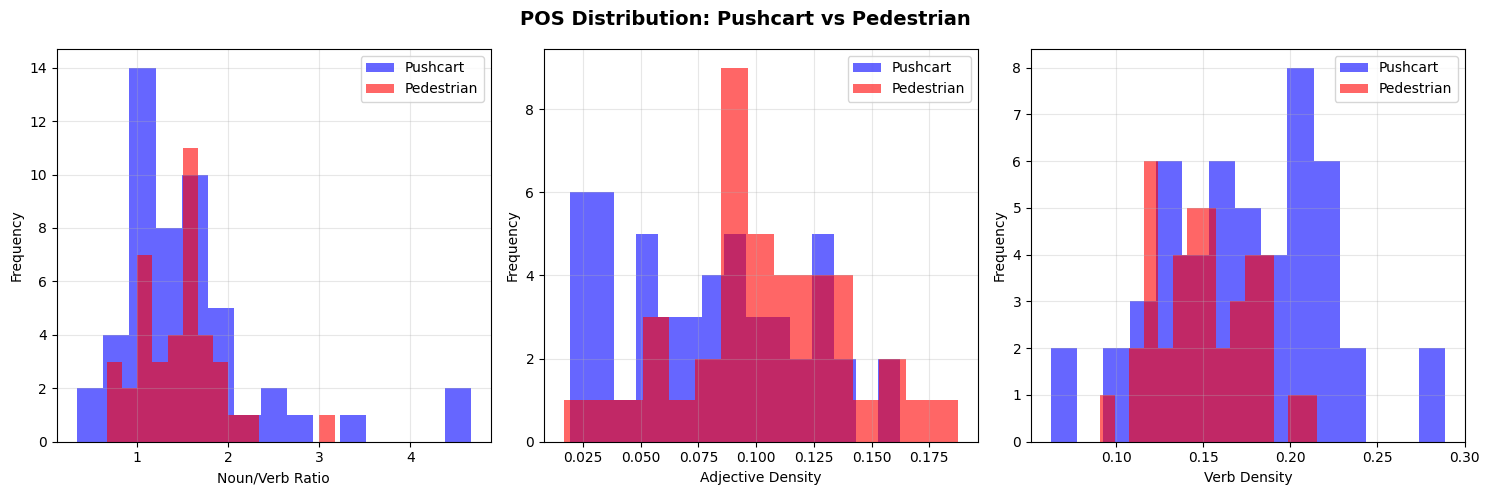

✓ POS distribution plots saved


In [21]:
# Plot POS distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['noun_verb_ratio', 'adj_density', 'verb_density']
titles = ['Noun/Verb Ratio', 'Adjective Density', 'Verb Density']

for ax, metric, title in zip(axes, metrics, titles):
    ax.hist(pushcart_pos[metric], alpha=0.6, label='Pushcart', bins=15, color='blue')
    ax.hist(pedestrian_pos[metric], alpha=0.6, label='Pedestrian', bins=15, color='red')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('POS Distribution: Pushcart vs Pedestrian', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}pos_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ POS distribution plots saved")

## STEP 2: Topic Modeling (LDA)

In [22]:
def prepare_corpus(poems, stopwords_set):
    """Prepare corpus for LDA"""
    texts = []
    for poem in poems:
        tokens = word_tokenize(poem['poem'].lower())
        # Remove stopwords and short words
        tokens = [t for t in tokens if t not in stopwords_set and len(t) > 3 and t.isalpha()]
        texts.append(tokens)
    return texts

# Prepare stopwords
stop_words = set(stopwords.words('english'))

# Prepare corpora
pushcart_texts = prepare_corpus(pushcart_poems, stop_words)
pedestrian_texts = prepare_corpus(pedestrian_poems, stop_words)

# Create dictionaries
pushcart_dict = corpora.Dictionary(pushcart_texts)
pedestrian_dict = corpora.Dictionary(pedestrian_texts)

# Create corpus
pushcart_corpus = [pushcart_dict.doc2bow(text) for text in pushcart_texts]
pedestrian_corpus = [pedestrian_dict.doc2bow(text) for text in pedestrian_texts]

print(f"✓ Pushcart corpus: {len(pushcart_corpus)} documents")
print(f"✓ Pedestrian corpus: {len(pedestrian_corpus)} documents")

✓ Pushcart corpus: 50 documents
✓ Pedestrian corpus: 40 documents


In [23]:
# Run LDA on Pushcart poems
num_topics = 6

print("Running LDA on Pushcart poems...")
pushcart_lda = models.LdaModel(
    pushcart_corpus,
    num_topics=num_topics,
    id2word=pushcart_dict,
    passes=15,
    random_state=42
)

print("\nPUSHCART TOPICS:")
print("="*60)
for idx, topic in pushcart_lda.print_topics(-1):
    print(f"Topic {idx}: {topic}")
    print()

Running LDA on Pushcart poems...

PUSHCART TOPICS:
Topic 0: 0.011*"self" + 0.011*"negotiation" + 0.011*"unfinished" + 0.006*"without" + 0.006*"small" + 0.006*"even" + 0.006*"feels" + 0.006*"sentence" + 0.006*"present" + 0.006*"clarity"

Topic 1: 0.014*"still" + 0.011*"language" + 0.011*"body" + 0.011*"step" + 0.008*"something" + 0.008*"self" + 0.008*"like" + 0.008*"identity" + 0.008*"present" + 0.008*"mirrors"

Topic 2: 0.013*"like" + 0.011*"absence" + 0.008*"something" + 0.008*"never" + 0.008*"carefully" + 0.008*"nothing" + 0.006*"feels" + 0.006*"answer" + 0.006*"becomes" + 0.006*"means"

Topic 3: 0.014*"without" + 0.010*"memory" + 0.010*"even" + 0.010*"still" + 0.010*"resolution" + 0.010*"leave" + 0.005*"silence" + 0.005*"anyway" + 0.005*"movement" + 0.005*"refuses"

Topic 4: 0.013*"identity" + 0.013*"remains" + 0.010*"name" + 0.010*"body" + 0.010*"still" + 0.007*"time" + 0.007*"temporary" + 0.007*"memory" + 0.007*"exist" + 0.007*"space"

Topic 5: 0.013*"like" + 0.009*"without" + 0.0

In [24]:
# Run LDA on pedestrian poems
print("Running LDA on pedestrian poems...")
pedestrian_lda = models.LdaModel(
    pedestrian_corpus,
    num_topics=num_topics,
    id2word=pedestrian_dict,
    passes=15,
    random_state=42
)

print("\nPEDESTRIAN TOPICS:")
print("="*60)
for idx, topic in pedestrian_lda.print_topics(-1):
    print(f"Topic {idx}: {topic}")
    print()

Running LDA on pedestrian poems...

PEDESTRIAN TOPICS:
Topic 0: 0.027*"feel" + 0.026*"walk" + 0.026*"every" + 0.020*"simple" + 0.016*"love" + 0.016*"trees" + 0.016*"along" + 0.016*"hand" + 0.016*"free" + 0.014*"feels"

Topic 1: 0.018*"night" + 0.017*"laugh" + 0.016*"feel" + 0.015*"world" + 0.013*"perfect" + 0.012*"bright" + 0.012*"feels" + 0.011*"start" + 0.011*"year" + 0.011*"watch"

Topic 2: 0.022*"side" + 0.015*"right" + 0.015*"watch" + 0.015*"hope" + 0.015*"always" + 0.015*"days" + 0.015*"plays" + 0.008*"peace" + 0.008*"falls" + 0.008*"gentle"

Topic 3: 0.022*"calm" + 0.019*"gentle" + 0.019*"inside" + 0.016*"rain" + 0.016*"watch" + 0.014*"light" + 0.013*"feel" + 0.013*"dreams" + 0.013*"steady" + 0.013*"soft"

Topic 4: 0.015*"walk" + 0.015*"upon" + 0.015*"love" + 0.015*"around" + 0.015*"found" + 0.015*"plays" + 0.015*"head" + 0.008*"calm" + 0.008*"drift" + 0.008*"peaceful"

Topic 5: 0.030*"every" + 0.025*"always" + 0.020*"bright" + 0.020*"love" + 0.015*"smile" + 0.015*"share" + 0.01

## STEP 3: Sentiment Analysis

In [25]:
vader = SentimentIntensityAnalyzer()

def analyze_sentiment(poem_text):
    """Analyze sentiment using TextBlob and VADER"""
    # TextBlob
    blob = TextBlob(poem_text)

    # VADER
    vader_scores = vader.polarity_scores(poem_text)

    # Calculate variance across lines (emotional complexity)
    lines = sent_tokenize(poem_text)
    line_polarities = [TextBlob(line).sentiment.polarity for line in lines]
    variance = np.var(line_polarities) if len(line_polarities) > 1 else 0

    return {
        'polarity': blob.sentiment.polarity,
        'subjectivity': blob.sentiment.subjectivity,
        'compound': vader_scores['compound'],
        'variance': variance
    }

# Analyze sentiment for all poems
print("Analyzing sentiment for Pushcart poems...")
for poem in pushcart_poems:
    poem['sentiment'] = analyze_sentiment(poem['poem'])

print("Analyzing sentiment for pedestrian poems...")
for poem in pedestrian_poems:
    poem['sentiment'] = analyze_sentiment(poem['poem'])

print("✓ Sentiment analysis complete")

Analyzing sentiment for Pushcart poems...
Analyzing sentiment for pedestrian poems...
✓ Sentiment analysis complete


In [26]:
# Create sentiment dataframes
pushcart_sent = pd.DataFrame([p['sentiment'] for p in pushcart_poems])
pedestrian_sent = pd.DataFrame([p['sentiment'] for p in pedestrian_poems])

print("PUSHCART POEMS - SENTIMENT STATISTICS")
print("="*60)
print(pushcart_sent.describe())

print("\nPEDESTRIAN POEMS - SENTIMENT STATISTICS")
print("="*60)
print(pedestrian_sent.describe())

PUSHCART POEMS - SENTIMENT STATISTICS
        polarity  subjectivity   compound   variance
count  50.000000     50.000000  50.000000  50.000000
mean   -0.017954      0.373853  -0.015060   0.015869
std     0.154681      0.233255   0.465185   0.024656
min    -0.500000      0.000000  -0.895700   0.000000
25%    -0.076373      0.211458  -0.362575   0.000136
50%     0.000000      0.365152   0.038600   0.004980
75%     0.059564      0.465625   0.337575   0.016330
max     0.400000      1.000000   0.740900   0.094940

PEDESTRIAN POEMS - SENTIMENT STATISTICS
        polarity  subjectivity   compound   variance
count  40.000000     40.000000  40.000000  40.000000
mean    0.242984      0.492488   0.894872   0.039990
std     0.127480      0.101922   0.143571   0.033318
min    -0.004762      0.133333   0.296000   0.000985
25%     0.146615      0.432048   0.889075   0.014014
50%     0.253810      0.511111   0.956400   0.038080
75%     0.329038      0.553919   0.969625   0.051547
max     0.538889    

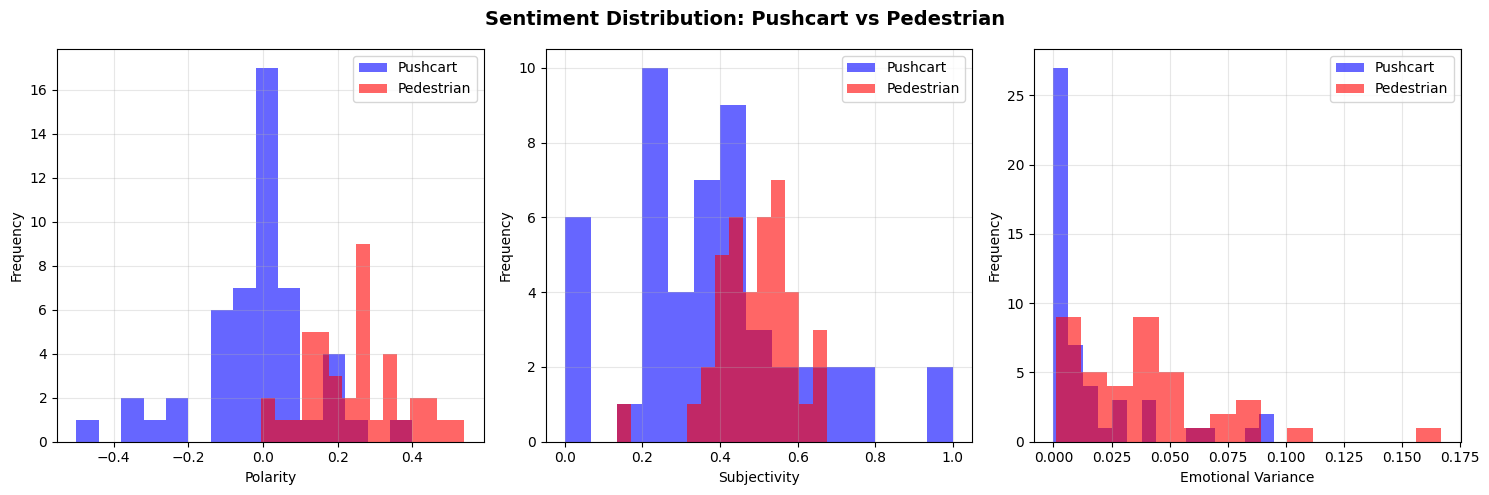

✓ Sentiment distribution plots saved


In [27]:
# Plot sentiment distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sent_metrics = ['polarity', 'subjectivity', 'variance']
sent_titles = ['Polarity', 'Subjectivity', 'Emotional Variance']

for ax, metric, title in zip(axes, sent_metrics, sent_titles):
    ax.hist(pushcart_sent[metric], alpha=0.6, label='Pushcart', bins=15, color='blue')
    ax.hist(pedestrian_sent[metric], alpha=0.6, label='Pedestrian', bins=15, color='red')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Sentiment Distribution: Pushcart vs Pedestrian', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}sentiment_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sentiment distribution plots saved")

## STEP 4: Create Gold Standard Profile

In [28]:
# Calculate Pushcart profile
pushcart_profile = {
    'pos': {
        'noun_verb_ratio': float(pushcart_pos['noun_verb_ratio'].mean()),
        'noun_verb_std': float(pushcart_pos['noun_verb_ratio'].std()),
        'adj_density': float(pushcart_pos['adj_density'].mean()),
        'adj_density_std': float(pushcart_pos['adj_density'].std()),
        'verb_density': float(pushcart_pos['verb_density'].mean()),
        'verb_density_std': float(pushcart_pos['verb_density'].std())
    },
    'topics': [
        # Extract top words from LDA topics
        # You'll manually identify themes from the LDA output above
        'mortality', 'human condition', 'society',
        'philosophy', 'nature', 'relationships'
    ],
    'sentiment': {
        'polarity_mean': float(pushcart_sent['polarity'].mean()),
        'polarity_std': float(pushcart_sent['polarity'].std()),
        'variance_mean': float(pushcart_sent['variance'].mean()),
        'variance_std': float(pushcart_sent['variance'].std()),
        'polarity_range': (float(pushcart_sent['polarity'].min()),
                          float(pushcart_sent['polarity'].max()))
    },
    'sample_size': len(pushcart_poems)
}

# Save profile
with open(f'{OUTPUT_DIR}pushcart_profile.json', 'w') as f:
    json.dump(pushcart_profile, f, indent=2)

print("PUSHCART GOLD STANDARD PROFILE")
print("="*60)
print(json.dumps(pushcart_profile, indent=2))
print()
print(f"✓ Profile saved to {OUTPUT_DIR}pushcart_profile.json")

PUSHCART GOLD STANDARD PROFILE
{
  "pos": {
    "noun_verb_ratio": 1.5530681540681541,
    "noun_verb_std": 0.8418954687878635,
    "adj_density": 0.07933891146383527,
    "adj_density_std": 0.03945578428812856,
    "verb_density": 0.17312218922974837,
    "verb_density_std": 0.049136971071113054
  },
  "topics": [
    "mortality",
    "human condition",
    "society",
    "philosophy",
    "nature",
    "relationships"
  ],
  "sentiment": {
    "polarity_mean": -0.01795400089328661,
    "polarity_std": 0.15468068836710208,
    "variance_mean": 0.015869190184032465,
    "variance_std": 0.02465556815976426,
    "polarity_range": [
      -0.5,
      0.4
    ]
  },
  "sample_size": 50
}

✓ Profile saved to ./pushcart_data/pushcart_profile.json


## Save Annotated Poems for Part 2

In [29]:
# Save all annotated poems
with open(f'{OUTPUT_DIR}pushcart_poems_analyzed.json', 'w') as f:
    json.dump(pushcart_poems, f, indent=2)

with open(f'{OUTPUT_DIR}pedestrian_poems_analyzed.json', 'w') as f:
    json.dump(pedestrian_poems, f, indent=2)

print("✓ Saved annotated poems")
print()
print("="*60)
print("PART 1 COMPLETE!")
print("="*60)
print()
print("Files created:")
print(f"  1. {OUTPUT_DIR}pushcart_profile.json (GOLD STANDARD)")
print(f"  2. {OUTPUT_DIR}pushcart_poems_analyzed.json")
print(f"  3. {OUTPUT_DIR}pedestrian_poems_analyzed.json")
print(f"  4. {OUTPUT_DIR}pos_distributions.png")
print(f"  5. {OUTPUT_DIR}sentiment_distributions.png")
print()
print("Next: Run Part 2 - FCoT Evolution!")

✓ Saved annotated poems

PART 1 COMPLETE!

Files created:
  1. ./pushcart_data/pushcart_profile.json (GOLD STANDARD)
  2. ./pushcart_data/pushcart_poems_analyzed.json
  3. ./pushcart_data/pedestrian_poems_analyzed.json
  4. ./pushcart_data/pos_distributions.png
  5. ./pushcart_data/sentiment_distributions.png

Next: Run Part 2 - FCoT Evolution!


## Download Files

In [30]:
from google.colab import files

# Download key files
files.download(f'{OUTPUT_DIR}pushcart_profile.json')
files.download(f'{OUTPUT_DIR}pushcart_poems_analyzed.json')
files.download(f'{OUTPUT_DIR}pedestrian_poems_analyzed.json')
files.download(f'{OUTPUT_DIR}pos_distributions.png')
files.download(f'{OUTPUT_DIR}sentiment_distributions.png')

print("✓ Downloads complete")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads complete
